# FA (IPFA) - beer dataset

In [1]:
#disable warnings
from warnings import simplefilter, filterwarnings
simplefilter(action='ignore', category=FutureWarning)
filterwarnings("ignore")

## beer dataset

In [2]:
# beer dataset
from scientisttools.datasets import beer
beer

,cost,size,alcohol,reputat,color,aroma,taste,rnd1,rnd2,rnd3,rnd4,rnd5,rnd6,rnd7
0,10,15,20,85,40,30,50,40,80,65,25,90,45,40
1,100,70,50,30,75,60,80,70,55,45,25,95,95,60
2,65,30,35,80,80,60,90,45,90,65,90,20,95,35
3,0,0,20,30,80,90,100,85,30,45,85,40,80,5
4,10,25,10,100,50,40,60,20,5,25,25,20,25,80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94,10,25,10,100,50,40,60,50,85,60,50,75,30,85
95,25,35,30,40,45,30,65,80,80,55,0,35,95,80
96,5,10,15,65,50,65,85,85,50,95,50,35,10,95
97,20,5,10,40,60,50,95,5,90,65,65,50,65,10


## Instanciation & training

In [3]:
#unrotated NIPFA
from scientisttools import FA
clf = FA(ncp=2,max_iter=50)

### `fit` function

In [4]:
#fit function
clf.fit(beer)

,max_iter,50
,method,'principal'
,scale_unit,True
,ncp,2
,row_w,None
,col_w,None
,ind_sup,None
,sup_var,None
,min_error,0.001
,warn_message,True
Name,Type,Value


### `fit_transform` function

In [5]:
# fit_transform - individuals coordinates
ind_coord = clf.fit_transform(beer)
ind_coord

,Dim1,Dim2
0,1.775913,-0.342211
1,-1.120308,-2.017477
2,-1.060667,-0.375162
3,-0.587064,1.315889
4,1.237011,-0.203594
...,...,...
94,1.188462,-0.197349
95,0.474356,-0.834631
96,0.139205,0.705487
97,0.349927,0.854658


### `transform` function

In [6]:
#transform - individuals coordinates
ind_coord = clf.transform(beer)
ind_coord

,Dim1,Dim2
0,1.775913,-0.342211
1,-1.120308,-2.017477
2,-1.060667,-0.375162
3,-0.587064,1.315889
4,1.237011,-0.203594
...,...,...
94,1.188462,-0.197349
95,0.474356,-0.834631
96,0.139205,0.705487
97,0.349927,0.854658


## Eigenvalues

In [7]:
#eigen values
from scientisttools import get_eig, fviz_screeplot
eig = get_eig(clf)
eig

,Eigenvalue,Difference,Proportion (%),Cumulative (%)
Dim1,3.171216,0.495965,46.534501,46.534501
Dim2,2.675250,2.334011,39.256692,85.791193
Dim3,0.341240,0.076312,5.007358,90.798551
Dim4,0.264928,0.099499,3.887559,94.686110
Dim5,0.165429,0.044656,2.427514,97.113624
Dim6,0.120773,0.044846,1.772225,98.885848
Dim7,0.075927,NaN,1.114152,100.000000


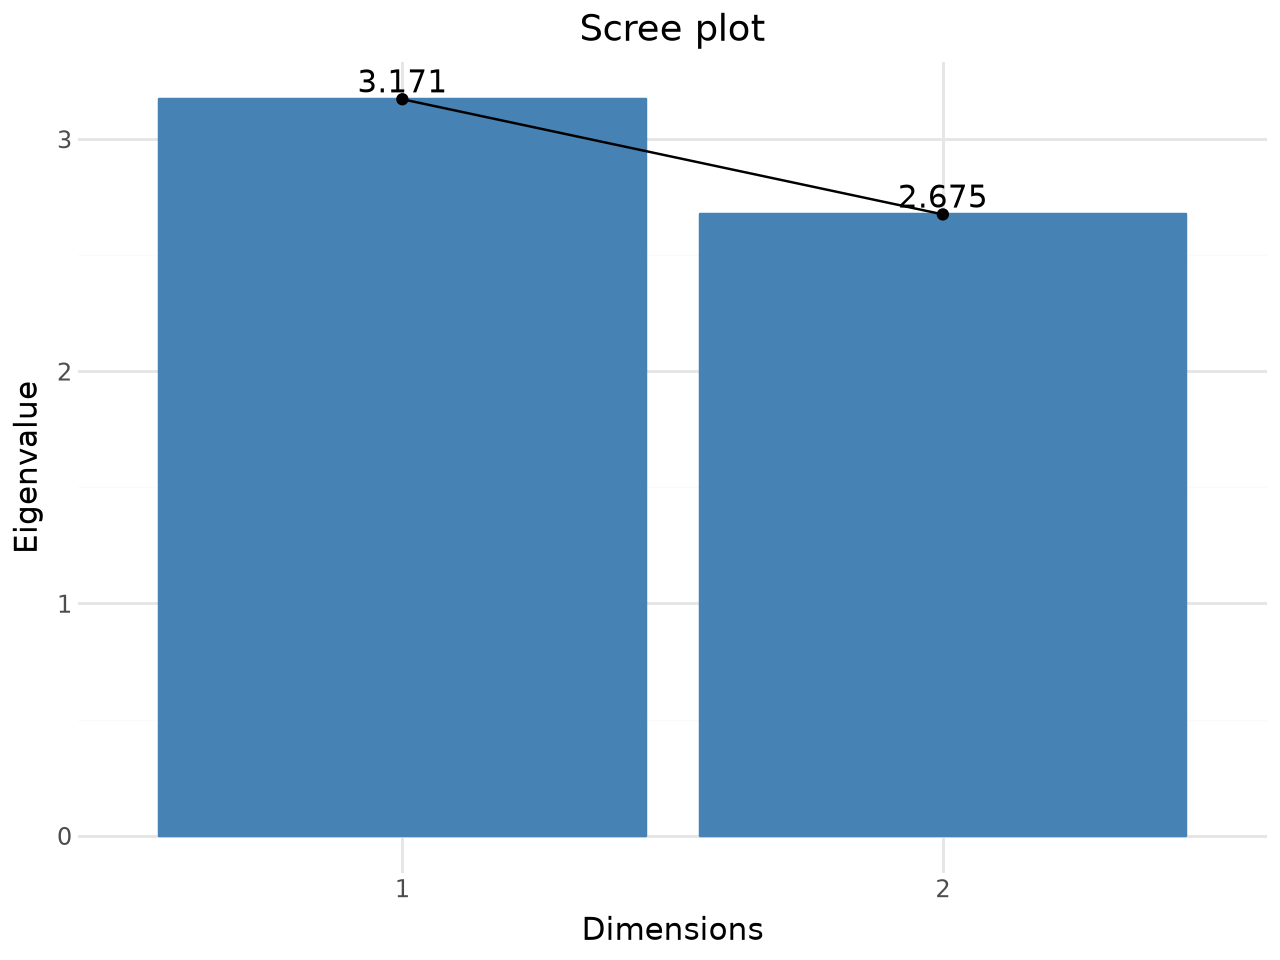

None


In [8]:
# screeplot
p = fviz_screeplot(
    obj = clf,
    choice = "eigenvalue",
    show_labels = True
)
print(p.show())

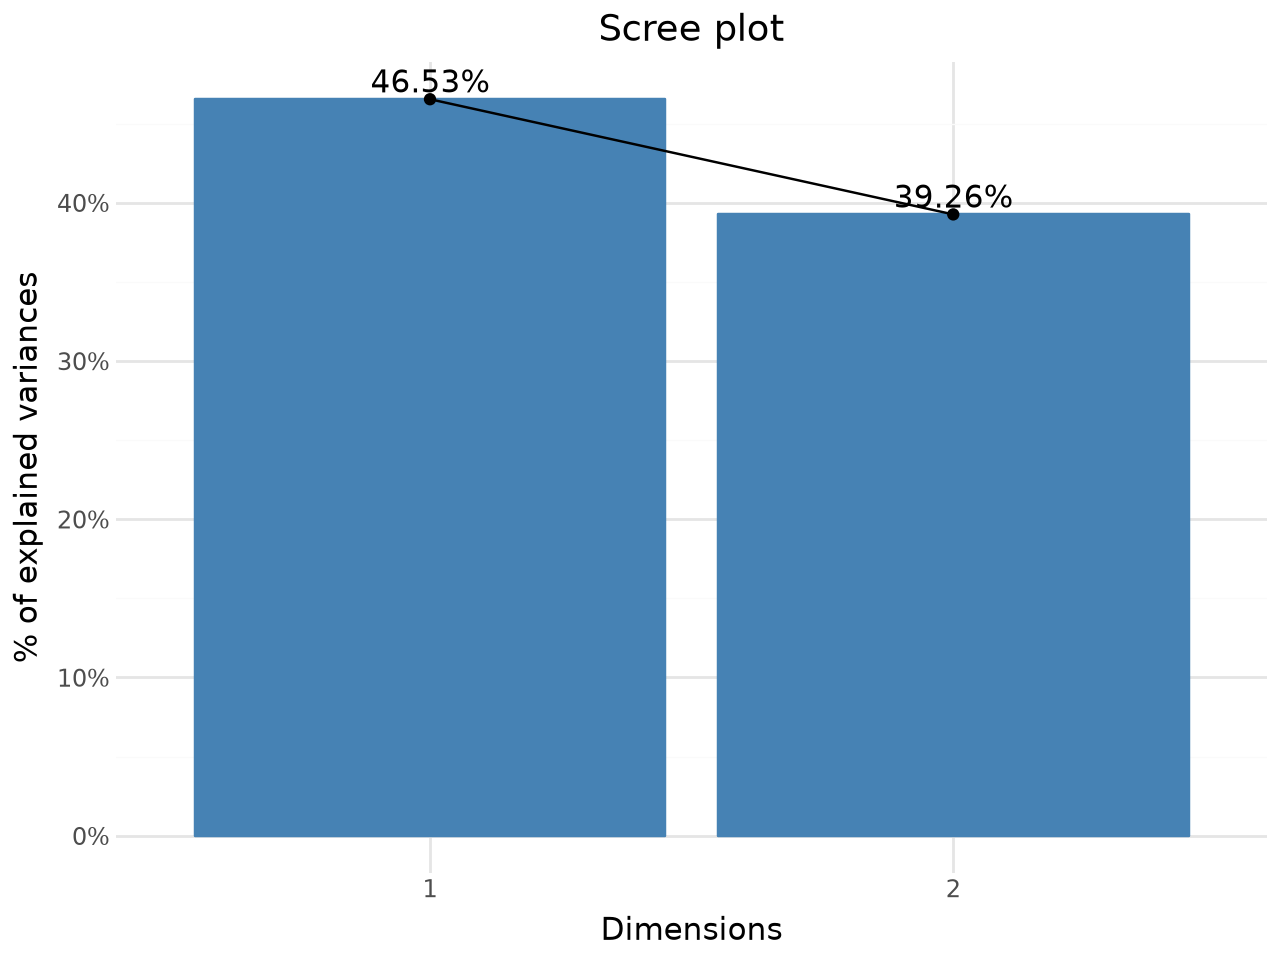

None


In [9]:
# proportion of variance
p = fviz_screeplot(
    obj = clf,
    choice = "proportion",
    show_labels = True
)
print(p.show())

## Variables

In [10]:
#variables
from scientisttools import get_fa
quanti_var = get_fa(clf,"var")
quanti_var._fields

('coord', 'contrib', 'infos')

### Variables coordinates (=loadings)

In [11]:
#variables coordinates (=loadings)
quanti_var.coord

,Dim1,Dim2
cost,-0.534644,-0.769637
size,-0.261605,-0.938874
alcohol,-0.624107,-0.718983
reputat,0.624745,-0.127341
color,-0.885328,0.223570
aroma,-0.751299,0.522730
taste,-0.792023,0.541477
rnd1,-0.027048,-0.201735
rnd2,-0.029744,0.059875
rnd3,-0.083759,-0.029915


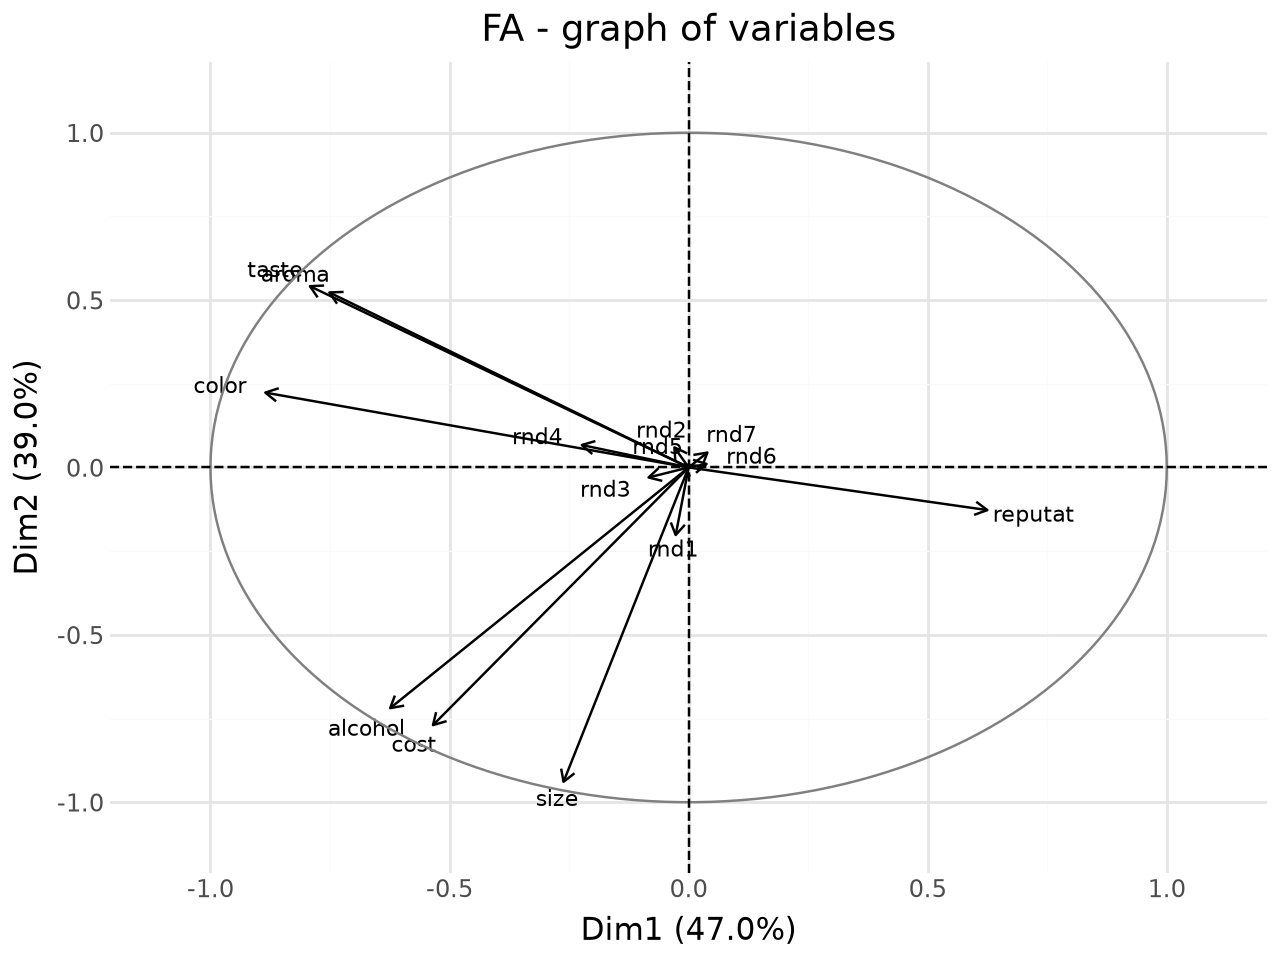

None


In [12]:
# correlation circle
from scientisttools import fviz_fa
p = fviz_fa(
    obj = clf,
    choice = "var",
    repel = True
)
print(p.show())

### Variables contributions

In [13]:
#variables contributions
quanti_var.contrib

,Dim1,Dim2
cost,19.591450,5.892445
size,13.816496,68.110776
alcohol,17.581172,9.123797
reputat,3.122408,0.084990
color,0.322475,0.864047
aroma,0.901156,4.122658
taste,44.446311,11.647837
rnd1,0.062306,0.000263
rnd2,0.023692,0.007439
rnd3,0.024532,0.043207


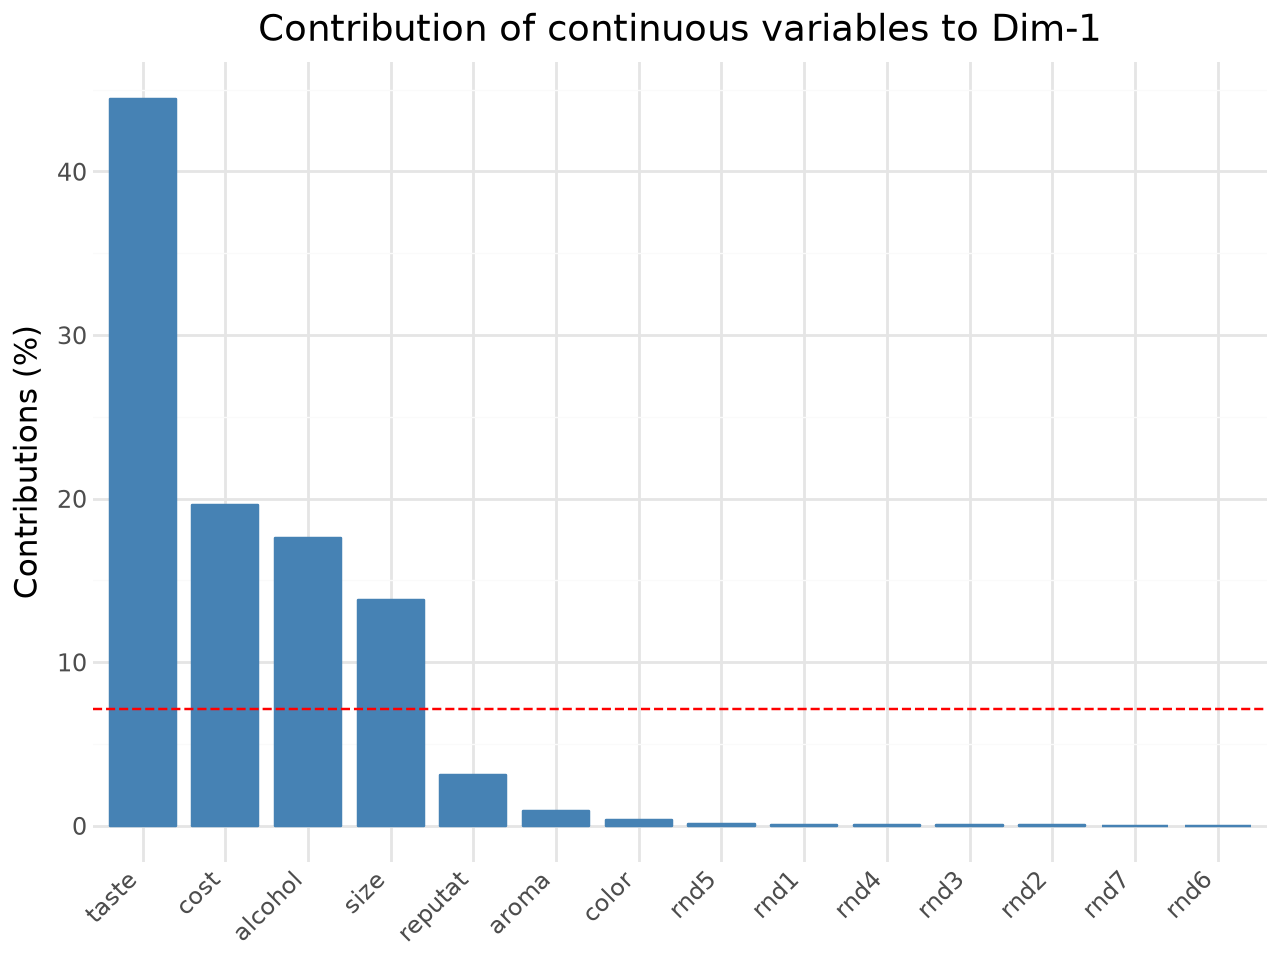

None


In [14]:
# contribution of continuous variables to Dim-1
from scientisttools import fviz_contrib
p = fviz_contrib(clf,"quanti_var")
print(p.show())

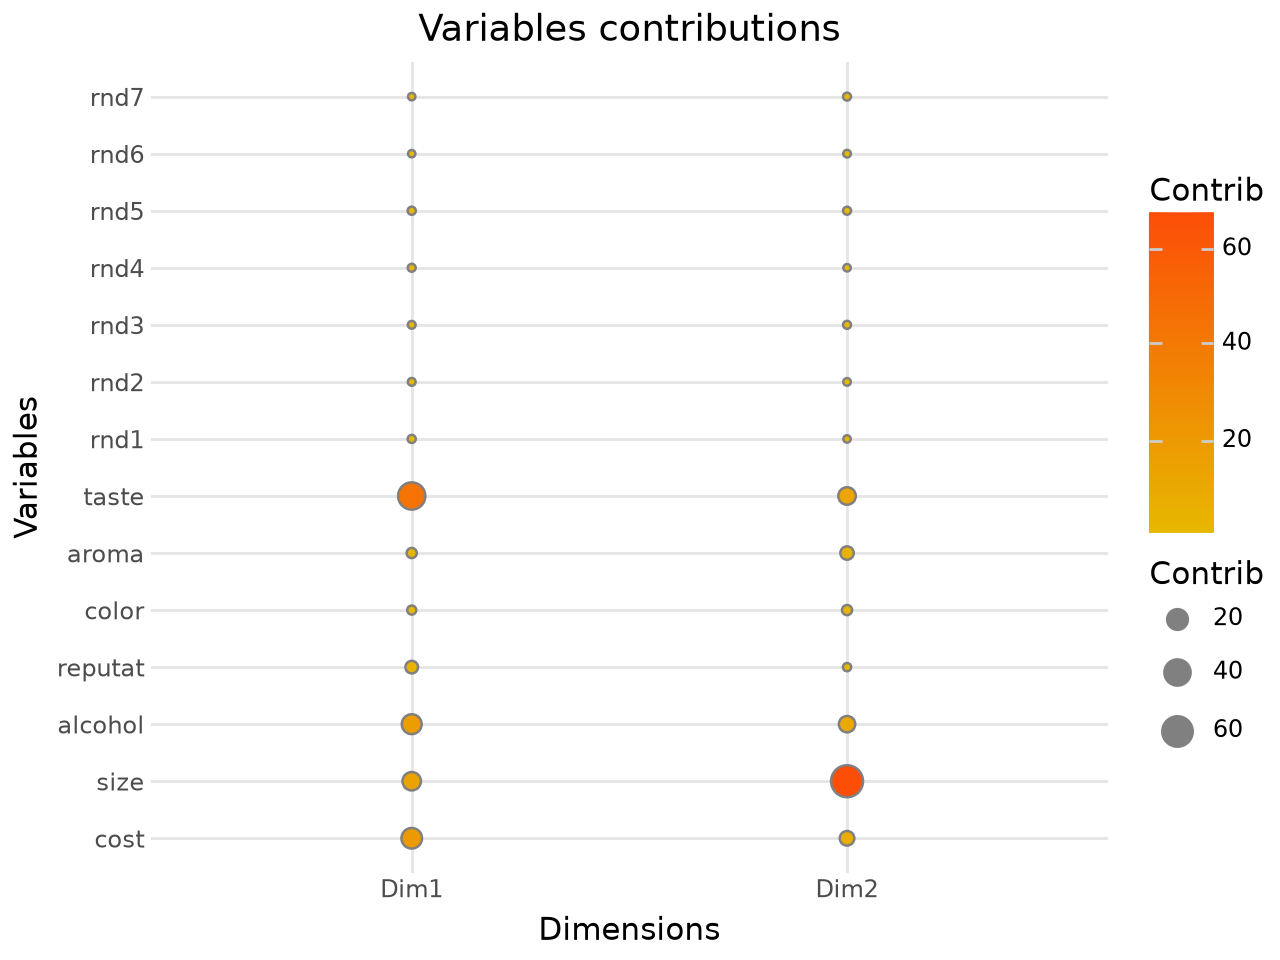

None


In [15]:
# variables contributions
from scientisttools import fviz_corrplot
p = fviz_corrplot(
    X = clf.quanti_var_.contrib,
    title="Variables contributions",
    legend_title="Contrib"
)
print(p.show())

### Variables additionals informations

In [16]:
# variables additionals informations
quanti_var.infos

,Weight,Prior,Final
cost,1.0,0.961050,0.878185
size,1.0,0.943887,0.949922
alcohol,1.0,0.912336,0.906447
reputat,1.0,0.772319,0.406522
color,1.0,0.853280,0.833789
aroma,1.0,0.886801,0.837698
taste,1.0,0.950270,0.920498
rnd1,1.0,0.138258,0.041428
rnd2,1.0,0.084953,0.004470
rnd3,1.0,0.073575,0.007911


## Individuals informations

In [17]:
# individuals informations
ind = get_fa(clf,"ind")
ind._fields

('coord',)

### Individuals coordinates

In [18]:
#individuals coordinates
ind.coord

,Dim1,Dim2
0,1.775913,-0.342211
1,-1.120308,-2.017477
2,-1.060667,-0.375162
3,-0.587064,1.315889
4,1.237011,-0.203594
...,...,...
94,1.188462,-0.197349
95,0.474356,-0.834631
96,0.139205,0.705487
97,0.349927,0.854658


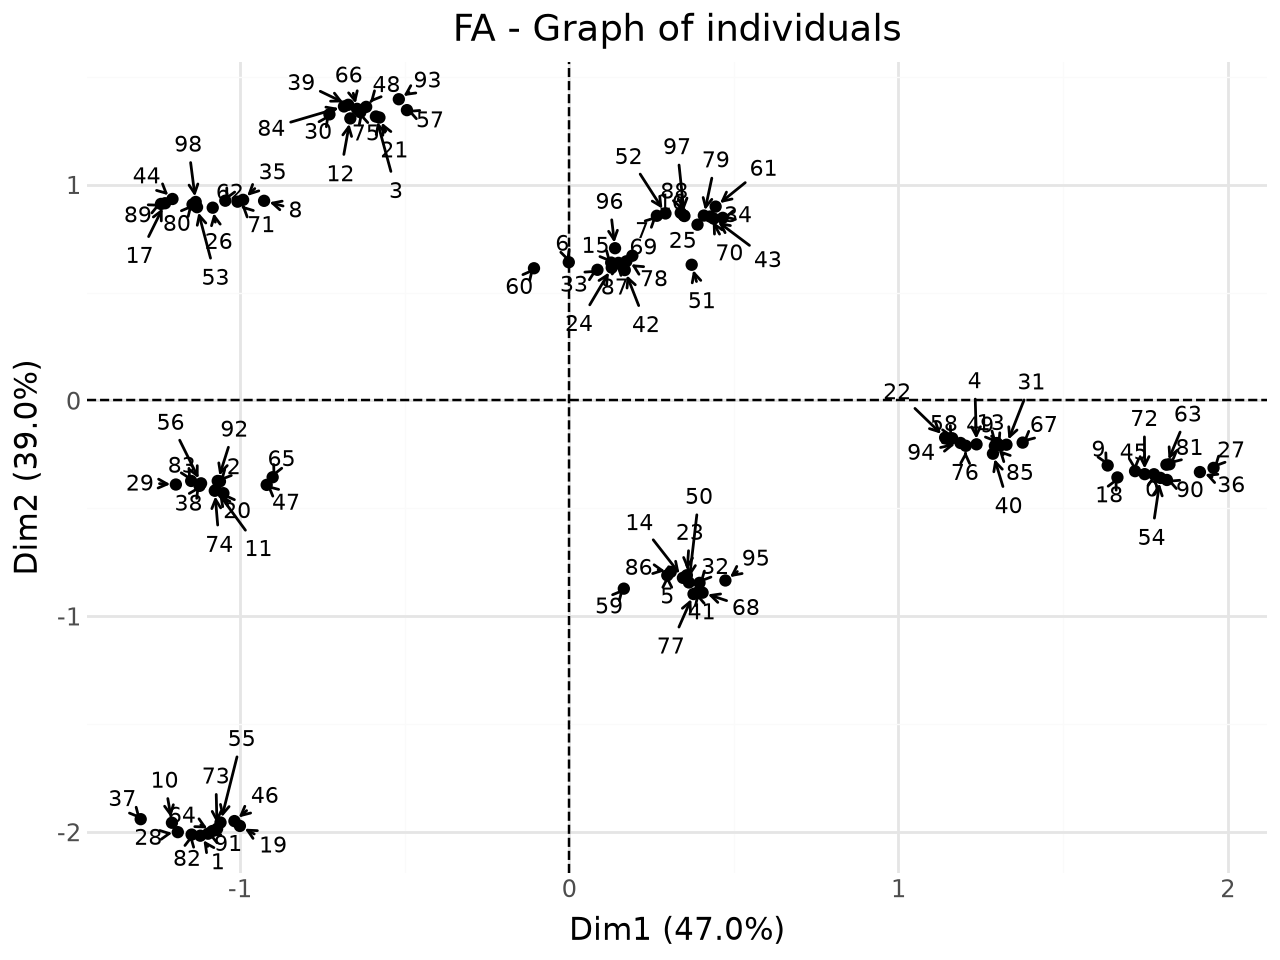

None


In [19]:
# individuals points
p = fviz_fa(
    obj = clf,
    choice = "ind",
    repel = True
)
print(p.show())

## Biplot

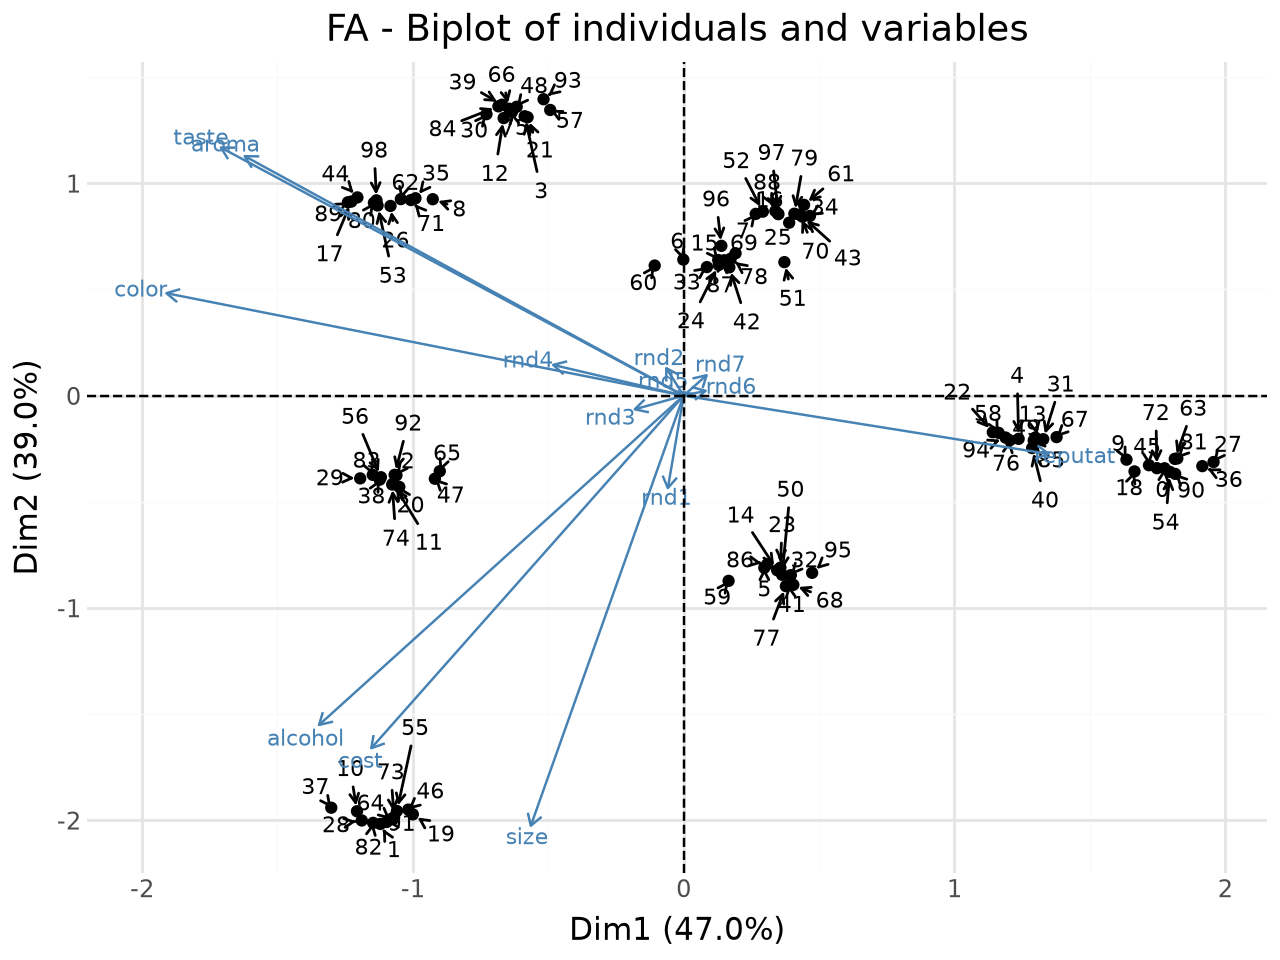

None


In [20]:
# biplot
p = fviz_fa(
    obj = clf,
    choice = "biplot",
    repel_ind = True,
    repel_var = True
)
print(p.show())

## Statistics with FA

In [21]:
# statistics for CA
from scientisttools import statsFA
stats = statsFA(clf)
stats._fields

('corr', 'others')

### Correlation

In [22]:
#correlation
corr = stats.corr
corr._fields

('corrcoef', 'pcorrcoef', 'reconst', 'residual')

#### Pearson correlation matrix

In [23]:
#pearson correlation matrox
corr.corrcoef

,cost,size,alcohol,reputat,color,aroma,taste,rnd1,rnd2,rnd3,rnd4,rnd5,rnd6,rnd7
cost,1.000000,0.878394,0.877019,-0.174783,0.320894,-0.027642,0.053982,0.166062,-0.051740,0.033018,0.101161,-0.001881,-0.022898,-0.062388
size,0.878394,1.000000,0.823668,-0.061234,0.014407,-0.286237,-0.307511,0.206038,-0.035755,0.059759,-0.021006,-0.038331,-0.000748,-0.026847
alcohol,0.877019,0.823668,1.000000,-0.360515,0.397697,0.097678,0.055805,0.182431,-0.028547,0.090211,0.076909,0.000802,-0.080030,-0.081195
reputat,-0.174783,-0.061234,-0.360515,1.000000,-0.523799,-0.521515,-0.626496,0.054200,0.053832,-0.097293,-0.150862,0.038719,-0.047220,0.090954
color,0.320894,0.014407,0.397697,-0.523799,1.000000,0.823244,0.804870,-0.014480,0.106898,0.061969,0.245058,0.024351,-0.085458,0.053949
aroma,-0.027642,-0.286237,0.097678,-0.521515,0.823244,1.000000,0.866073,-0.045175,0.067048,0.043716,0.151902,0.038739,-0.051204,-0.012857
taste,0.053982,-0.307511,0.055805,-0.626496,0.804870,0.866073,1.000000,-0.082160,0.034088,-0.003334,0.206091,-0.012485,0.027340,-0.041157
rnd1,0.166062,0.206038,0.182431,0.054200,-0.014480,-0.045175,-0.082160,1.000000,0.067112,-0.043945,-0.106403,0.187147,0.104980,-0.038058
rnd2,-0.051740,-0.035755,-0.028547,0.053832,0.106898,0.067048,0.034088,0.067112,1.000000,-0.013165,0.063579,0.067021,0.056613,0.070214
rnd3,0.033018,0.059759,0.090211,-0.097293,0.061969,0.043716,-0.003334,-0.043945,-0.013165,1.000000,0.156839,-0.073910,0.071880,0.014219


#### Partial pearson correlation matrix

In [24]:
#partial pearson correlation matrox
corr.pcorrcoef

,cost,size,alcohol,reputat,color,aroma,taste,rnd1,rnd2,rnd3,rnd4,rnd5,rnd6,rnd7
cost,1.000000,0.820162,0.606899,0.695902,0.041644,-0.604287,0.796466,-0.112835,-0.171570,-0.011951,0.134970,0.185414,-0.019552,-0.071346
size,0.820162,1.000000,-0.124221,-0.522308,-0.078193,0.398832,-0.672197,0.117718,0.149532,0.002381,-0.125876,-0.193811,0.089426,0.114562
alcohol,0.606899,-0.124221,1.000000,-0.632505,0.322078,0.402476,-0.592952,0.133218,0.047764,0.012310,-0.072889,-0.083627,-0.082374,-0.104707
reputat,0.695902,-0.522308,-0.632505,1.000000,0.160328,0.416750,-0.767395,0.144765,0.142295,-0.067045,-0.101510,-0.125778,-0.027657,0.032215
color,0.041644,-0.078193,0.322078,0.160328,1.000000,0.352250,0.269313,-0.046095,0.157291,0.048110,0.119991,-0.005908,-0.090712,0.230538
aroma,-0.604287,0.398832,0.402476,0.416750,0.352250,1.000000,0.668571,-0.028785,-0.100662,0.064347,-0.034785,0.161202,-0.056172,-0.070665
taste,0.796466,-0.672197,-0.592952,-0.767395,0.269313,0.668571,1.000000,0.099868,0.082736,-0.088281,-0.059324,-0.193950,0.105593,-0.028986
rnd1,-0.112835,0.117718,0.133218,0.144765,-0.046095,-0.028785,0.099868,1.000000,0.042474,-0.031680,-0.091187,0.219977,0.132345,-0.024035
rnd2,-0.171570,0.149532,0.047764,0.142295,0.157291,-0.100662,0.082736,0.042474,1.000000,-0.028028,0.067000,0.072015,0.077198,0.009493
rnd3,-0.011951,0.002381,0.012310,-0.067045,0.048110,0.064347,-0.088281,-0.031680,-0.028028,1.000000,0.161500,-0.080395,0.098288,-0.001235


#### Reproduced correlation matrix

In [25]:
#reproduced correlation matrox
corr.reconst

,cost,size,alcohol,reputat,color,aroma,taste,rnd1,rnd2,rnd3,rnd4,rnd5,rnd6,rnd7
cost,0.878185,0.862458,0.887031,-0.236010,0.301267,-0.000635,0.006709,0.169723,-0.030180,0.067805,0.067826,-0.002207,-0.028109,-0.055219
size,0.862458,0.949922,0.838304,-0.043879,0.021702,-0.294235,-0.301182,0.196479,-0.048434,0.049998,-0.004509,-0.006257,-0.019617,-0.052030
alcohol,0.887031,0.838304,0.906447,-0.298352,0.391797,0.093057,0.104994,0.161925,-0.024486,0.073783,0.091205,-0.000925,-0.030941,-0.056477
reputat,-0.236010,-0.043879,-0.298352,0.406522,-0.581574,-0.535936,-0.563765,0.008791,-0.026207,-0.048519,-0.148087,-0.006873,0.022140,0.018857
color,0.301267,0.021702,0.391797,-0.581574,0.833789,0.782013,0.822258,-0.021155,0.039719,0.067466,0.212745,0.010137,-0.030925,-0.024804
aroma,-0.000635,-0.294235,0.093057,-0.535936,0.782013,0.837698,0.878093,-0.085132,0.053645,0.047291,0.202864,0.011668,-0.022771,-0.006236
taste,0.006709,-0.301182,0.104994,-0.563765,0.822258,0.878093,0.920498,-0.087812,0.055979,0.050141,0.213217,0.012213,-0.024106,-0.007001
rnd1,0.169723,0.196479,0.161925,0.008791,-0.021155,-0.085132,-0.087812,0.041428,-0.011274,0.008300,-0.007483,-0.001611,-0.003120,-0.010035
rnd2,-0.030180,-0.048434,-0.024486,-0.026207,0.039719,0.053645,0.055979,-0.011274,0.004470,0.000700,0.010658,0.000823,-0.000493,0.001496
rnd3,0.067805,0.049998,0.073783,-0.048519,0.067466,0.047291,0.050141,0.008300,0.000700,0.007911,0.016704,0.000489,-0.003458,-0.004618


#### Residual correlation matrix

In [26]:
#residual correlation matrox
corr.residual

,cost,size,alcohol,reputat,color,aroma,taste,rnd1,rnd2,rnd3,rnd4,rnd5,rnd6,rnd7
cost,NaN,0.015936,-0.010012,0.061227,0.019627,-0.027007,0.047273,-0.003661,-0.021560,-0.034788,0.033336,0.000326,0.005211,-0.007169
size,0.015936,NaN,-0.014636,-0.017355,-0.007295,0.007998,-0.006329,0.009558,0.012679,0.009760,-0.016496,-0.032074,0.018869,0.025183
alcohol,-0.010012,-0.014636,NaN,-0.062163,0.005900,0.004621,-0.049189,0.020507,-0.004061,0.016427,-0.014297,0.001726,-0.049088,-0.024718
reputat,0.061227,-0.017355,-0.062163,NaN,0.057774,0.014421,-0.062731,0.045409,0.080038,-0.048775,-0.002775,0.045593,-0.069360,0.072098
color,0.019627,-0.007295,0.005900,0.057774,NaN,0.041231,-0.017388,0.006675,0.067179,-0.005498,0.032313,0.014214,-0.054532,0.078752
aroma,-0.027007,0.007998,0.004621,0.014421,0.041231,NaN,-0.012020,0.039956,0.013403,-0.003575,-0.050961,0.027071,-0.028433,-0.006621
taste,0.047273,-0.006329,-0.049189,-0.062731,-0.017388,-0.012020,NaN,0.005652,-0.021890,-0.053475,-0.007126,-0.024698,0.051445,-0.034156
rnd1,-0.003661,0.009558,0.020507,0.045409,0.006675,0.039956,0.005652,NaN,0.078387,-0.052246,-0.098920,0.188757,0.108100,-0.028023
rnd2,-0.021560,0.012679,-0.004061,0.080038,0.067179,0.013403,-0.021890,0.078387,NaN,-0.013865,0.052920,0.066198,0.057105,0.068718
rnd3,-0.034788,0.009760,0.016427,-0.048775,-0.005498,-0.003575,-0.053475,-0.052246,-0.013865,NaN,0.140136,-0.074399,0.075339,0.018837


### Others statistics

In [27]:
# others statistics
others = stats.others
others._fields

('vaccounted', 'explained_variance', 'communalities', 'inertia')

#### Variances accounted

In [28]:
#variances accounted
others.vaccounted

,Dim1,Dim2
Original,3.386557,2.794665
Common,3.171216,2.675250
SS loadings,3.171216,2.675250
Proportion Var (%),22.651539,19.108930
Cumulative Var (%),22.651539,41.760469
Proportion Explained (%),54.241582,45.758418
Cumulative Proportion (%),54.241582,100.000000


#### Explained variance

In [29]:
# explained variance
others.explained_variance

,Weighted,Unweighted,R2
Dim1,3.171216,3.171216,1.012172
Dim2,2.675250,2.675250,0.970614


#### Communalities

In [30]:
#communalities
round(others.communalities,4)

5.8465

#### Inertia

In [31]:
#inertia
round(others.inertia,4)

7.0137

## Others elements

### Summary

In [32]:
# summary
from scientisttools import summary
summary(clf)

                     Factor Analysis - Results                     

Importance of components:
      Eigenvalue  Difference  Proportion (%)  Cumulative (%)
Dim1      3.1712       0.496         46.5345         46.5345
Dim2      2.6753       2.334         39.2567         85.7912

Individuals (the 10 first):
     Dim1    Dim2
0  1.7759 -0.3422
1 -1.1203 -2.0175
2 -1.0607 -0.3752
3 -0.5871  1.3159
4  1.2370 -0.2036
5  0.2979 -0.8107
6 -0.0013  0.6405
7  0.2662  0.8559
8 -0.9266  0.9251
9  1.6353 -0.3016

Continuous (the 10 first):
           Dim1      ctr    Dim2      ctr
cost    -0.5346  19.5915 -0.7696   5.8924
size    -0.2616  13.8165 -0.9389  68.1108
alcohol -0.6241  17.5812 -0.7190   9.1238
reputat  0.6247   3.1224 -0.1273   0.0850
color   -0.8853   0.3225  0.2236   0.8640
aroma   -0.7513   0.9012  0.5227   4.1227
taste   -0.7920  44.4463  0.5415  11.6478
rnd1    -0.0270   0.0623 -0.2017   0.0003
rnd2    -0.0297   0.0237  0.0599   0.0074
rnd3    -0.0838   0.0245 -0.0299   0.0432
